<a href="https://colab.research.google.com/github/Sara-beep/data-projects/blob/main/Study_graphics_subjects.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Estudio de asignaturas preferidas

In [68]:
import pandas as pd

import matplotlib.pyplot as plt

df = pd.read_csv('https://fpaniaguapython.github.io/datos/materias_estudio.csv')
df

,Unnamed: 0,LITERATURA,MATEMÁTICAS,FÍSICA,TECNOLOGÍA,HISTORIA,RELIGIÓN,CIENCIAS,FILOSOFÍA
0,NaN,5,10,5,9,2,7,10,2
1,NaN,8,9,7,20,8,7,8,7
2,NaN,10,8,8,6,10,5,9,10
3,NaN,5,6,7,8,9,5,7,8
4,NaN,6,8,7,8,7,3,8,0
5,NaN,4,8,3,10,6,-10,5,7
6,NaN,7,3,5,8,10,2,10,9
7,NaN,8,6,6,10,9,1,9,9
8,NaN,5,10,8,10,9,8,9,1
9,NaN,4,8,8,9,10,2,8,5


In [69]:
df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   0 non-null      float64
 1   LITERATURA   16 non-null     int64  
 2   MATEMÁTICAS  16 non-null     int64  
 3   FÍSICA       16 non-null     int64  
 4   TECNOLOGÍA   16 non-null     int64  
 5   HISTORIA     16 non-null     int64  
 6   RELIGIÓN     16 non-null     int64  
 7   CIENCIAS     16 non-null     int64  
 8   FILOSOFÍA    16 non-null     int64  
dtypes: float64(1), int64(8)
memory usage: 1.3 KB


eliminar columna

In [70]:
df = df.drop(columns=['Unnamed: 0'])

In [71]:
df.info(
)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16 entries, 0 to 15
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   LITERATURA   16 non-null     int64
 1   MATEMÁTICAS  16 non-null     int64
 2   FÍSICA       16 non-null     int64
 3   TECNOLOGÍA   16 non-null     int64
 4   HISTORIA     16 non-null     int64
 5   RELIGIÓN     16 non-null     int64
 6   CIENCIAS     16 non-null     int64
 7   FILOSOFÍA    16 non-null     int64
dtypes: int64(8)
memory usage: 1.1 KB


Saber que columnas tienen outliers

In [72]:

for columna in df.columns:
    outliers = df[(df[columna] < 0) | (df[columna] > 10)]
    print(f"Columna {columna}: {outliers[[columna]].values}")




Columna LITERATURA: []
Columna MATEMÁTICAS: []
Columna FÍSICA: []
Columna TECNOLOGÍA: [[20]]
Columna HISTORIA: []
Columna RELIGIÓN: [[-10]]
Columna CIENCIAS: []
Columna FILOSOFÍA: []


convertir los valores ourliers en null

In [73]:
df = df.applymap(lambda x: x if 0 <= x <= 10 else None)

df.head()

/tmp/ipykernel_13838/3829488890.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x if 0 <= x <= 10 else None)


,LITERATURA,MATEMÁTICAS,FÍSICA,TECNOLOGÍA,HISTORIA,RELIGIÓN,CIENCIAS,FILOSOFÍA
0,5,10,5,9.0,2,7.0,10,2
1,8,9,7,NaN,8,7.0,8,7
2,10,8,8,6.0,10,5.0,9,10
3,5,6,7,8.0,9,5.0,7,8
4,6,8,7,8.0,7,3.0,8,0


eliminar los nulls

In [74]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, 0 to 15
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   LITERATURA   14 non-null     int64  
 1   MATEMÁTICAS  14 non-null     int64  
 2   FÍSICA       14 non-null     int64  
 3   TECNOLOGÍA   14 non-null     float64
 4   HISTORIA     14 non-null     int64  
 5   RELIGIÓN     14 non-null     float64
 6   CIENCIAS     14 non-null     int64  
 7   FILOSOFÍA    14 non-null     int64  
dtypes: float64(2), int64(6)
memory usage: 1008.0 bytes


crear grafica

In [75]:
correlacion = df.corr()
correlacion

,LITERATURA,MATEMÁTICAS,FÍSICA,TECNOLOGÍA,HISTORIA,RELIGIÓN,CIENCIAS,FILOSOFÍA
LITERATURA,1.000000,-0.169788,0.207073,-0.244217,0.488448,0.124105,0.490482,0.325440
MATEMÁTICAS,-0.169788,1.000000,0.391385,0.240830,-0.270308,0.460639,0.217020,-0.406076
FÍSICA,0.207073,0.391385,1.000000,0.419542,0.601854,-0.141450,0.028450,0.015425
TECNOLOGÍA,-0.244217,0.240830,0.419542,1.000000,0.092584,-0.132450,0.157552,-0.151271
HISTORIA,0.488448,-0.270308,0.601854,0.092584,1.000000,-0.280824,0.130587,0.432840
RELIGIÓN,0.124105,0.460639,-0.141450,-0.132450,-0.280824,1.000000,0.286896,-0.032784
CIENCIAS,0.490482,0.217020,0.028450,0.157552,0.130587,0.286896,1.000000,0.138058
FILOSOFÍA,0.325440,-0.406076,0.015425,-0.151271,0.432840,-0.032784,0.138058,1.000000


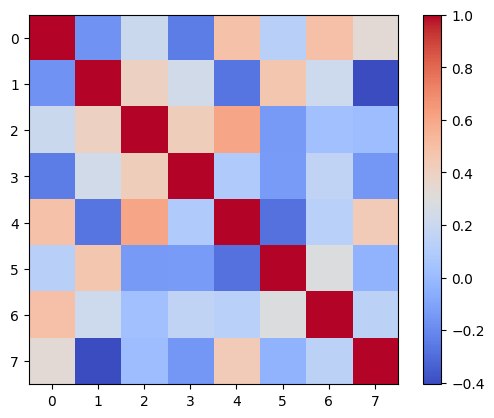

In [76]:
img = plt.imshow(correlacion, cmap = 'coolwarm')
plt.colorbar(img)
plt.show()

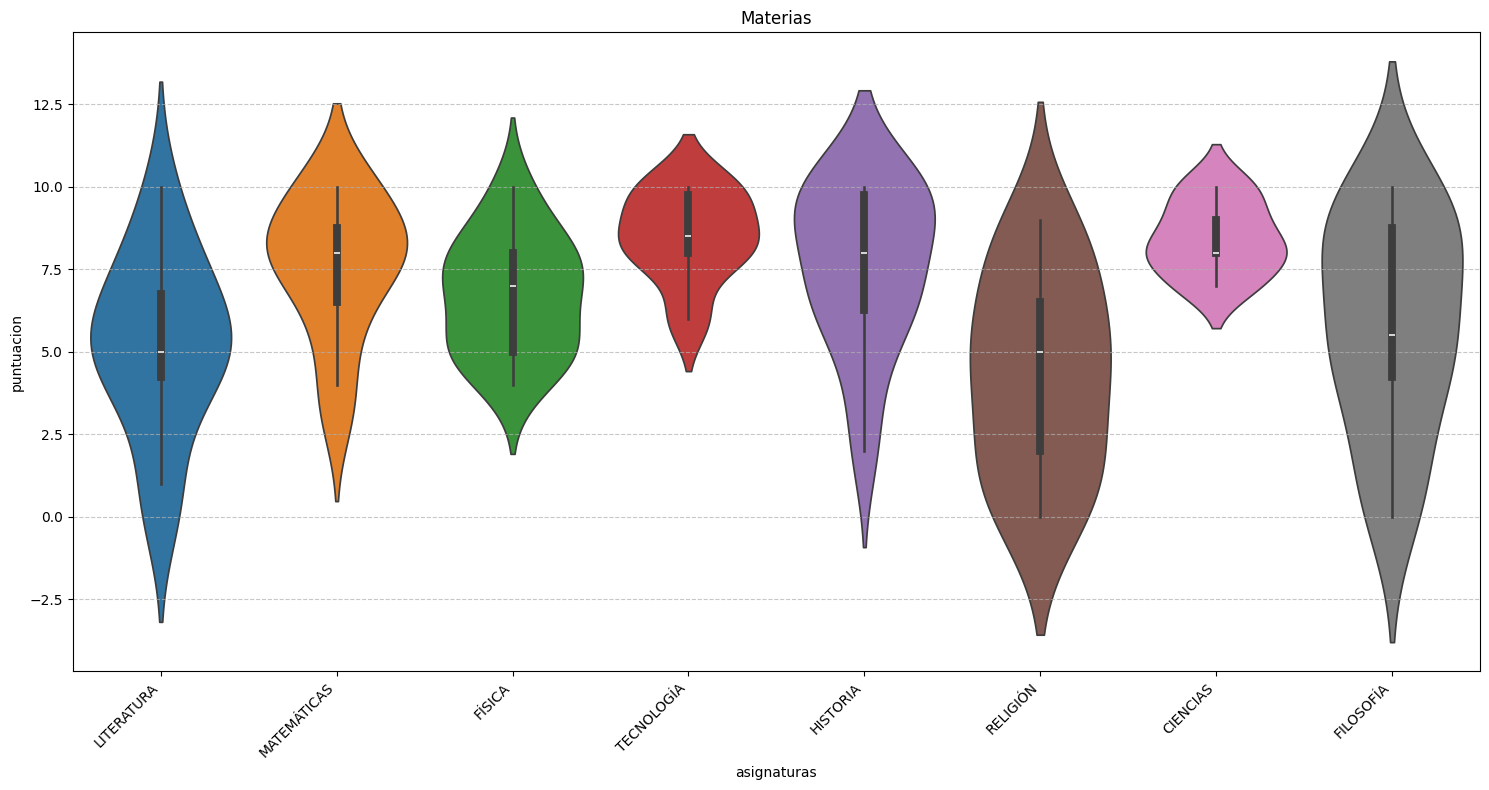

In [78]:
import seaborn as sns

plt.figure(figsize=(15, 8))
sns.violinplot(data=df)
plt.title('Materias')
plt.ylabel('puntuacion')
plt.xlabel('asignaturas')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()